# Matplotlib

Ariketa multzo honek **matplotlib** liburutegiaren oinarrizko eragiketak lantzen ditu, Ikaskuntza Automatikoan (ML) erabilgarriak diren datuen esplorazioa, ereduen ebaluazioa eta abarren gaitasunak landuz.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Ezarri irudiaren tamaina lehenetsia hazbetetan (zabalera, altuera)
mpl.rcParams['figure.figsize'] = (5.33,4)
# Ezarri ardatzen eta marka-etiketen letra-tamaina lehenetsia puntutan
mpl.rcParams['axes.labelsize'] = 10  # Adibidea: 10 puntu
mpl.rcParams['xtick.labelsize'] = 8  # Adibidea: 8 puntu x ardatzeko marketarako
mpl.rcParams['ytick.labelsize'] = 8  # Adibidea: 8 puntu y ardatzeko marketarako

##  Errendimendu eta Galera Kurbak

**1 - Galera-kurba (Loss Curve):** Demagun eredu batek duen galera (*loss*) funtziaren kurbak $y_{train} = e^{-0.2x}$ itsura duela, $x$ ardatzeko balioak entrenamendu garaiak direlarik (*epochs*, iterazioak direla suposatu, $[1,50]$ tartean). Marraztu ezazu kurba hori ([plt.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)), ezarri titulu bat eta izendatu ardatzak (*Epochs* eta *Loss*).

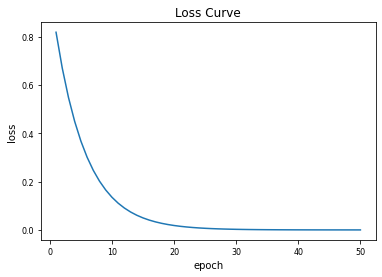

In [7]:
x = np.arange(1,51)
y = np.exp(-0.2*x)
plt.axes().set(xlabel='epoch', ylabel='loss', title='Loss Curve')
plt.plot(x, y);

**2 - Entrenamendua vs. Balioztatzea (Overfitting):** Aurreko adibidearekin jarraituz, demagun balioztatze-galera (*validation loss*, test-galera dela suposatu) kurbak $y_{val} = e^{-0.15x} + 0.01x$ itsura duela. Marraztu ezazu grafiko berean entrenamenduko galera eta balioztatze-galera, ezarri titulu bat,  ardatzak izendatu eta gehitu legenda bi lerroak bereizteko.


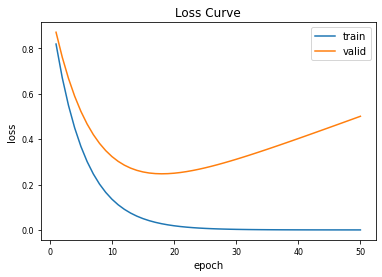

In [15]:
x = np.arange(1,51)
y_train = np.exp(-0.2*x)
y_valid = np.exp(-0.15*x) + 0.01 * x
plt.axes().set(xlabel='epoch', ylabel='loss', title='Loss Curve')
plt.plot(x, y_train, label='train')
plt.plot(x, y_valid, label='valid')
plt.legend();

**3 - Lerro-estiloak metrika anitzetan:** Demagun eredu bat 50 *epoch*-etan entrenatzean bi metrika erabili direla, Zehaztasuna (*Accuracy*) eta Prezisioa (*Precision*) eta bi metrika horien kurbek $y_{acc}=0.8-e^{-0.2x}$ eta $y_{prec}=\max \{0 ,\, 0.7-e^{-0.1x}\}$ itsura dutela. Irudikatu *epoch*-etan zehar lortutako *Accuracy* eta *Precision* metrikak. Erabili lerro jarraitua bata marrazteko eta puntu bidezkoa (`--`) bestearentzat, kolore desberdinekin.

In [27]:
x = np.arange(1,51)
np.max([np.zeros(len(x)),0.7-np.exp(-0.1*x)], axis=0)

array([0.        , 0.        , 0.        , 0.02967995, 0.09346934,
       0.15118836, 0.2034147 , 0.25067104, 0.29343034, 0.33212056,
       0.36712892, 0.39880579, 0.42746821, 0.45340304, 0.47686984,
       0.49810348, 0.51731648, 0.53470111, 0.55043138, 0.56466472,
       0.57754357, 0.58919684, 0.59974116, 0.60928205, 0.617915  ,
       0.62572642, 0.63279449, 0.63918994, 0.64497678, 0.65021293,
       0.6549508 , 0.6592378 , 0.66311683, 0.66662673, 0.66980262,
       0.67267628, 0.67527647, 0.67762923, 0.67975809, 0.68168436,
       0.68342732, 0.68500442, 0.68643144, 0.68772266, 0.688891  ,
       0.68994816, 0.69090472, 0.69177025, 0.69255342, 0.69326205])

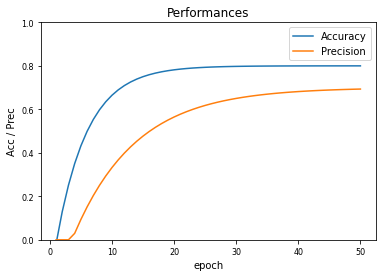

In [32]:
x = np.arange(1,51)
y_acc = 0.8-np.exp(-0.2*x)
y_prec = np.max([np.zeros(len(x)),0.7-np.exp(-0.1*x)], axis=0)
plt.axes().set(xlabel='epoch', ylabel='Acc / Prec', title='Performances', ylim=(0,1))
plt.plot(x, y_acc, label='Accuracy')
plt.plot(x, y_prec, label='Precision')
plt.legend();

## Sakabanatze-Diagramak eta Ezaugarrien Espazioa (Scatter Plots)


**4 - Bi ezaugarritako sakabanatze-diagrama:** Sortu ezazu $n=1000$ laginez eta bi ezaugarriz osotutako $(n \times 2)$ tamainako $X$ ezaugarri matrize bat. Laginak auzazki sortu $\mathcal{N}\left( \boldsymbol{\mu}, \boldsymbol{\Sigma} \right)$ banaketaren arabera, non

$$\boldsymbol{\mu} = \begin{pmatrix} 0 \\ 15 \end{pmatrix}, \quad \boldsymbol{\Sigma} = \begin{pmatrix} \sigma_x^2 & 0 \\ 0 & \sigma_y^2 \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & 10 \end{pmatrix}$$

Ondoren $X$ ezaugarri matrizeko datu-puntuen sakabanatze-diagrama bat ([`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)) marraztu.

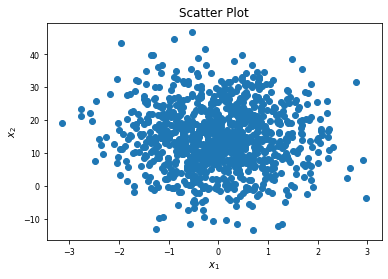

In [35]:
n = 1000
X = np.zeros((n,2))
X[:,0] = np.random.normal(loc=0, scale=1, size=(X.shape[0],))
X[:,1] = np.random.normal(loc=15, scale=10, size=(X.shape[0],))
plt.axes().set(xlabel='$x_1$', ylabel='$x_2$', title='Scatter Plot')
plt.scatter(X[:,0], X[:,1]);

**5 - Klaseak koloreztatzea (`c` eta `cmap`):** Aurreko ezaugarri matrizea erabiliz, sortu ezazu $n$ luzerako $\boldsymbol{y}$ klase/etiketa bektore bat, zeinaren balioak $X$-ko lehenengo ezaugarriaren zeinua adierazten duen, $1$ positiboa denean eta $0$ negatiboa denean. $X$ ezaugarri matrizeko datu-puntuen sakabanatze-diagrama bat ([`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)) marraztu eta erabili ezazu $\boldsymbol{y}$ bektorea puntuen kolore adierazle gisa `c=y` argumentuaren bidez. Froga itzazu [*kolore paleta*](https://matplotlib.org/stable/users/explain/colors/colormaps.html) ezberdinak (`cmap='viridis'`, `cmap='coolwarm'`, `cmap='rainbow'`, `cmap='cool'`...)

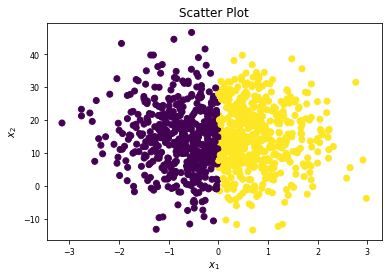

In [36]:
y = 0 + (X[:,0] >= 0)
plt.axes().set(xlabel='$x_1$', ylabel='$x_2$', title='Scatter Plot')
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis');

**6 - Hirugarren ezaugarria dimentsionatzea:** Aurreko $\mathcal{N}\left( \boldsymbol{\mu}, \boldsymbol{\Sigma} \right)$ banaketa berdinarekin sortu ezazu orain $n=50$ tamainako $X$ ezaugarri matrize bat. Gehitu iezaiozu hirugarren ezaugarri bat, $[0,1000)$ arteko auzazko balioz osotua. Marraztu lehenengo bi ezaugarrien sakabanatze diagrama eta hirugarren ezaugarria `s` parametroari esleitu, puntu bakoitzaren magnitudea bistaratzeko. Jokatu ezazu `alpha` parametroarekin, zeinak puntuen gardentasuna kontrolatzen duen (`alpha=0` guztiz gardena eta `alpha=1.0` guztiz opakua)

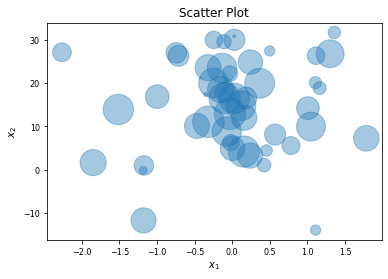

In [37]:
n = 50
X = np.zeros((n,3))
X[:,0] = np.random.normal(loc=0, scale=1, size=(X.shape[0],))
X[:,1] = np.random.normal(loc=15, scale=10, size=(X.shape[0],))
X[:,2] = 1000*np.random.rand(X.shape[0])

plt.axes().set(xlabel='$x_1$', ylabel='$x_2$', title='Scatter Plot')
plt.scatter(X[:,0], X[:,1], s=X[:,2], alpha=0.4);

**7 - Erregresio-lerroa datuen gainean:**

Demagun erregresio eredu lineal sinple bat dugula: $y = 0.7x + 3.5$ . Sortu ezazu $[0,10]$ tartean linealki banatua dagoen $n=300$ tamainako $\boldsymbol{x}$ bektore bat. $\boldsymbol{x}$ bektoreko balioekin, sortu ezazu $\boldsymbol{y}$ bektore bat, zeinetan ereduak aurresandako $y$ balioa eta $[-1,1]$ tarteko auzazko balio baten batura egongo den ($\boldsymbol{x}$-ko puntu bakoitzak, ausazko balio ezberdin bat izango du). Marraztu $\boldsymbol{x},\boldsymbol{y}$ datu-puntu sakabanatuak eta, horien gainean, ereduaren erregresio-lerro zuzena, $y = 0.7x + 3.5$. Jokatu ezazu `scatter` funtzioaren `marker='<ZEINU_BAT>'` eta `c='<KOLORE_IZEN_BAT>'` parametroekin eta `plot` funtzioaren `linewidth=<ILARA_ZABALERA>` parametroarekin irudi atseginago bat lortzeko.

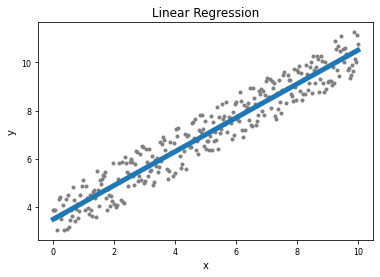

In [39]:
x = np.linspace(0, 10, 300)
y = 0.7 * x + 3.5
y2 = y + 2*np.random.rand(x.shape[0]) - 1

plt.axes().set(xlabel='x', ylabel='y', title='Linear Regression')
plt.scatter(x, y2, marker='.', c='grey')
plt.plot(x, y, linewidth=5);

## Datu-Banaketak eta Ezaugarrien Azterketa (EDA)

**8 - Ezaugarri baten histograma:** Sortu ezazu ezaugarri jarraitu bakarra duen $n=1000$ tamainako $\boldsymbol{x}$ bektore bat ($\mathcal{N}(\mu,\sigma)$ banaketa bat erabiliz) eta marraztu bere banaketa ([`plt.hist`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)) 30 `bins` erabiliz.

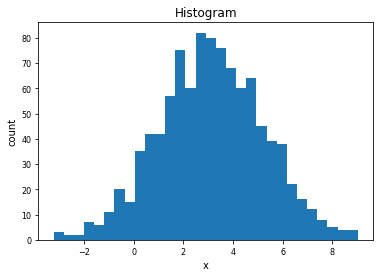

In [40]:
n = 1000
x = np.random.normal(loc=3, scale=2, size=(n,))
plt.axes().set(xlabel='x', ylabel='count', title='Histogram')
plt.hist(x, bins=30);

**9 - Klaseen araberako banaketa gainjarria:** Sortu aurreko ariketako moduko bi $\boldsymbol{x_{0}}$ eta $\boldsymbol{x_{1}}$ bektore (bakoitza batazbesteko eta desbiderapen estandar ezberdinarekin). Sortu itzazu $\boldsymbol{y_{0}}=[0,0,\dots,0]$ eta $\boldsymbol{y_{1}}=[1,1,\dots,1]$ bi etiketa bektore. Nahastu datu guztiak, $\boldsymbol{x}$ eta $\boldsymbol{y}$ bakarra sortuz, baina $x_i$ bakoitzari dagokion $y_i$ etiketa zuzena izaten jarrai dezan. $\boldsymbol{x}$ eta $\boldsymbol{y}$ bektoreetatik habiatuz, marraztu bi klase ezberdinen ezaugarrien histogramak grafiko berean, gardentasuna erabiliz (`alpha=0.5`) bi banaketak konparatu ahal izateko. 

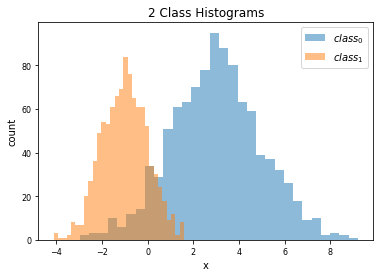

In [102]:
n = 1000
x0 = np.random.normal(loc=3, scale=2, size=(n,))
x1 = np.random.normal(loc=-1, scale=1, size=(n,))
y0 = np.zeros(n)
y1 = np.ones(n)

x = np.concatenate((x0, x1))
y = np.concatenate((y0, y1))

index = np.arange(2*n)
np.random.shuffle(index)
x = x[index]
y = y[index]

mask_0 = y == 0
mask_1 = y == 1
x0,y0 = x[mask_0],y[mask_0]
x1,y1 = x[mask_1],y[mask_1]

plt.axes().set(xlabel='x', ylabel='count', title='2 Class Histograms')
plt.hist(x0, bins=30, alpha=0.5, label='$class_0$')
plt.hist(x1, bins=30, alpha=0.5, label='$class_1$')
plt.legend();

**10 - Klaseen desoreka (Bar Plot):** Sortu ezazu $n=1000$ tamainako auzazko $\boldsymbol{y}$ etiketa bektorea, $\{0,1\}$ balioez osatua, etiketa bakoitza $1$ izateko probabilitatea $0.3$ delarik. Sortu barra-diagrama bat ([`plt.bar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html)) klase bakoitzaren instantzia kopurua erakusteko (*Class Imbalance* hautemateko).

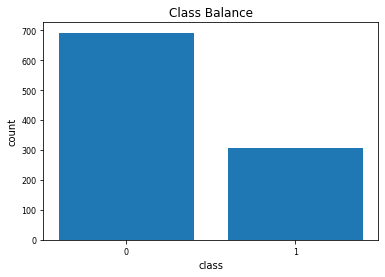

In [112]:
n = 1000
#y = 0 + (np.random.rand(n) > 0.7)
y = np.random.choice([0, 1], size=n, p=[0.7, 0.3])
height = [n-np.sum(y),np.sum(y)]
plt.axes().set(xlabel='class', ylabel='count', title='Class Balance')
plt.bar(["0","1"], height);

**11 - Outlier-ak hautematea (Boxplot):** Sortu ezazu $n=1000$ tamainako auzazko $\boldsymbol{y}$ etiketa bektorea, $\{0,1\}$ balioez osatua, etiketa bakoitza $1$ izateko probabilitatea $0.3$ delarik. Sortu barra-diagrama bat ([`plt.bar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html)) klase bakoitzaren instantzia kopurua erakusteko (*Class Imbalance* hautemateko).

Sortu `boxplot` bat datu-multzoko 4 ezaugarri ezberdinen banaketa eta balio atipikoak (*outliers*) ikusteko.


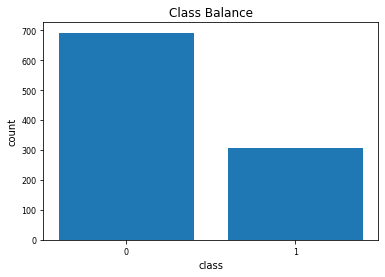

In [112]:
n = 1000
#y = 0 + (np.random.rand(n) > 0.7)
y = np.random.choice([0, 1], size=n, p=[0.7, 0.3])
height = [n-np.sum(y),np.sum(y)]
plt.axes().set(xlabel='class', ylabel='count', title='Class Balance')
plt.bar(["0","1"], height);

In [108]:
?plt.bar



11. **Outlier-ak hautematea (Boxplot):** Sortu `boxplot` bat datu-multzoko 4 ezaugarri ezberdinen banaketa eta balio atipikoak (*outliers*) ikusteko.

**4. Azpigrafikoak eta Sare-Egiturak (Subplots)**

12. **Ezaugarri anitzen panela ($2 \times 2$ Grid):** Sortu $2 \times 2$ saretako azpigrafiko panel bat (`plt.subplots`), non azpigrafiko bakoitzean dataset bateko ezaugarri baten histograma erakusten den.
13. **Ardatz bikoitzeko grafikoa (`twinx`):** Irudikatu entrenamenduko galera (ezkerreko Y ardatza) eta zehaztasuna (eskuineko Y ardatza) grafiko bakar batean `ax.twinx()` erabiliz.
14. **Balio errealak vs. Iragarpenak:** Sortu bi azpigrafiko alboko ($1 \times 2$): lehenengoan erakutsi datuen klase errealak eta bigarrenean ereduak iragartatutako klaseak.

**5. Matrizeak, Bero-Mapak eta Irudiak**

15. **Nahasmen Matrizea (Confusion Matrix):** Irudikatu $3 \times 3$ neurriko nahasmen-matrize bat `plt.imshow` erabiliz eta idatzi balio numerikoak gelaxka bakoitzaren barruan testu bidez.
16. **Korrelazio Matrizea:** Sortu ezaugarrien arteko korrelazio-matrize baten bero-mapa (*heatmap*) eta gehitu kolore-barra azalgarria (`plt.colorbar`).
17. **Irudi bat bisualizatzea (Fashion-MNIST simulazioa):** Erakutsi $28 \times 28$ matrize baten balioak (irudi bat) zuri-beltzean (`cmap='gray'`) eta kendu ardatzetako zenbakiak (`plt.axis('off')`).
18. **Irudi-sarea (Image Grid):** Sortu $3 \times 3$ azpigrafikoko sare bat datu-multzoko ausazko 9 irudi erakusteko beren jatorrizko etiketarekin batera izenburu gisa.

**6. Pertsonalizazio Aurreratua eta Exportazioa**

19. **Oharrak eta Puntu Kritikoak (Annotations):** Entrenamendu-kurba batean, gehitu testu-ohar bat eta gezi bat (`plt.annotate`) *Early Stopping* aplikatu beharko litzatekeen puntua markatzeko.
20. **Irudia kalitate altuan gordetzea:** Konfiguratu irudiaren neurria (`figsize=(10, 6)`), gehitu sareta atzealdean (`plt.grid(True)`), eta gorde PNG formatuan 300 DPIko bereizmenarekin (`plt.savefig`).